## Plotando um Scatter Plot Brasileirão 25 - 33ª Rodada

 Vamos criar um gráfico de dispersão dos times xG(Expected Goals) e xGA(Expected Goals Against), mas com os logotipos dos clubes representando cada um.

In [1]:
# ========================
# STD LIBS (Python nativo)
# ========================
import json
import time
import random
import subprocess
from pathlib import Path
from io import StringIO

# ==========================
# TERCEIROS (dados & web)
# ==========================
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup

# ==========================
# SELENIUM (automação web)
# ==========================
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException

# Opções para Firefox
from selenium.webdriver.firefox.options import Options


# ==========================
# VISUALIZAÇÃO (gráficos)
# ==========================
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot

# ==========================
# JUPYTER MAGIC (Notebook)
# ==========================
%matplotlib inline

# ==========================
# AJUSTE PANDAS (exibir tudo)
# ==========================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# ==========================
# ALERTAS (remover alertas)
# ==========================
import warnings
warnings.filterwarnings("ignore")


In [2]:

# ========== 1) Iniciar o Tor ==========
try:
    # ajuste o caminho se necessário 
    tor_path = r"C:\Tor\Browser\TorBrowser\Tor\tor.exe"
    subprocess.Popen([tor_path])
    print("[INFO] Tor iniciado com sucesso.")
except Exception as e:
    print(f"[ERRO] Falha ao iniciar o Tor: {e}")

# dá um tempo pro Tor subir
time.sleep(10)

# ========== 2) Configurar Firefox via Tor ==========
agentes = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.75 Safari/537.36",
]
agente = random.choice(agentes)

options = Options()
# Proxy SOCKS5 do Tor
options.set_preference("network.proxy.type", 1)
options.set_preference("network.proxy.socks", "127.0.0.1")
options.set_preference("network.proxy.socks_port", 9050)
options.set_preference("network.proxy.socks_remote_dns", True)

# User-Agent custom
options.set_preference("general.useragent.override", agente)


options.set_preference("dom.webdriver.enabled", False)
options.set_preference("media.peerconnection.enabled", False)  # desabilita WebRTC
options.set_preference("privacy.trackingprotection.enabled", True)

# Headless se quiser (opcional):
# options.add_argument("-headless")

# Se o geckodriver não estiver no PATH, baixe e coloque o .exe no PATH, ou use webdriver-manager
driver = webdriver.Firefox(options=options)

# ========== 3) Abrir e reaproveitar HTML renderizado ==========
try:
    # (opcional) testar o IP via Tor
    driver.get("https://check.torproject.org/")
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
    print("[INFO] Página de verificação do Tor carregada.")

    api_url = "https://fbref.com/en/comps/24/Serie-A-Stats"
    print(f"[1/1] Acessando: {api_url}")
    driver.get(api_url)

    # aguarda aparecer pelo menos 1 tabela
    WebDriverWait(driver, 25).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
    )

    html = driver.page_source  # HTML da aba atual aberta via Selenium
    table = pd.read_html(StringIO(html))  # lê TODAS as tabelas encontradas

    # pegue ID conforme necessário
    tabela_brasileirao = table[9]
    print(tabela_brasileirao.head())

    # Exportar para CSV
    tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\raw\Stats_2024_Serie_A.csv', index=False)
    print("Tabela extraída com sucesso!")
    
except Exception as e:
    print(f"[ERRO] Falha no fluxo Selenium+Tor: {e}")
finally:
    driver.quit()  # feche quando terminar
    pass


[INFO] Tor iniciado com sucesso.
[INFO] Página de verificação do Tor carregada.
[1/1] Acessando: https://fbref.com/en/comps/24/Serie-A-Stats
   Rk      Squad  MP   W   D   L  GF  GA  GD  Pts  Pts/MP    xG   xGA   xGD  \
0   1  Palmeiras  32  21   5   6  58  28  30   68    2.13  48.2  28.4  19.8   
1   2   Flamengo  32  20   8   4  64  20  44   68    2.13  48.9  26.8  22.1   
2   3   Cruzeiro  33  18  10   5  46  22  24   64    1.94  43.0  30.7  12.3   
3   4   Mirassol  33  16  11   6  54  33  21   59    1.79  49.1  38.6  10.5   
4   5      Bahia  33  15   8  10  44  40   4   53    1.61  42.5  42.1   0.4   

   xGD/90     Last 5  Attendance              Top Team Scorer     Goalkeeper  \
0    0.62  L D W W L       33800             Vitor Roque - 16       Wéverton   
1    0.69  W L W D W       56213  Giorgian De Arrascaeta - 17  Agustín Rossi   
2    0.37  W D W W D       44439              Kaio Jorge - 17         Cássio   
3    0.32  W W D L W        6175                Reinaldo - 11   

In [3]:
import pandas as pd

def clean_fbref_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Se colunas forem MultiIndex (FBRef), usa o 2º nível (nomes reais).
    - Para colunas cujo 1º nível == 'Per 90 Minutes', adiciona sufixo '_90'.
    - Mantém 'Performance' sem mudanças.
    """
    if not isinstance(df.columns, pd.MultiIndex):
        return df  # nada a fazer

    new_cols = []
    for col in df.columns:
        # col é uma tupla (nivel0, nivel1)
        g = str(col[0]).strip() if len(col) > 1 else ""
        name = str(col[1]).strip() if len(col) > 1 else str(col[0]).strip()

        # Alguns vêm como 'Unnamed: 0_level_0' etc. -> ignora
        if g.lower().startswith("unnamed"):
            g = ""

        # Regra: apenas Per 90 Minutes ganha _90
        if g == "Per 90 Minutes":
            name = f"{name}_90"

        new_cols.append(name)

    df = df.copy()
    df.columns = new_cols
    return df


In [4]:
#limpando as colunas 
tabela_brasileirao = clean_fbref_cols(tabela_brasileirao)

In [5]:
tabela_brasileirao

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,xG,xGA,xGD,xGD/90,Last 5,Attendance,Top Team Scorer,Goalkeeper,Notes
0,1,Palmeiras,32,21,5,6,58,28,30,68,2.13,48.2,28.4,19.8,0.62,L D W W L,33800,Vitor Roque - 16,Wéverton,NaN
1,2,Flamengo,32,20,8,4,64,20,44,68,2.13,48.9,26.8,22.1,0.69,W L W D W,56213,Giorgian De Arrascaeta - 17,Agustín Rossi,NaN
2,3,Cruzeiro,33,18,10,5,46,22,24,64,1.94,43.0,30.7,12.3,0.37,W D W W D,44439,Kaio Jorge - 17,Cássio,NaN
3,4,Mirassol,33,16,11,6,54,33,21,59,1.79,49.1,38.6,10.5,0.32,W W D L W,6175,Reinaldo - 11,Walter,NaN
4,5,Bahia,33,15,8,10,44,40,4,53,1.61,42.5,42.1,0.4,0.01,W L W L D,37301,Willian José - 10,Ronaldo,NaN
5,6,Botafogo (RJ),33,14,10,9,44,28,16,52,1.58,42.8,33.8,9.0,0.27,W D D W D,16971,"Alex Telles, Chris Ramos... - 4",John,NaN
6,7,Fluminense,33,15,6,12,38,37,1,51,1.55,34.7,31.3,3.4,0.10,W W L W D,29781,Germán Cano - 6,Fábio,NaN
7,8,São Paulo,33,12,9,12,37,36,1,45,1.36,41.3,39.4,1.9,0.06,L W W D L,37390,Luciano - 8,Rafael Pires,NaN
8,9,Atlético Mineiro,32,11,10,11,34,34,0,43,1.34,34.1,35.2,-1.1,-0.03,L W D W W,25886,"Rony, Hulk - 6",Éverson,NaN
9,10,Vasco da Gama,33,12,6,15,50,49,1,42,1.27,41.2,48.0,-6.8,-0.21,W W L L L,21539,Pablo Vegetti - 14,Léo Jardim,NaN


In [6]:
#salvando tabela cabeçalho limpo

tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\stats_2024_Serie_A.csv', index=False)

In [7]:
#Limpando os dados
colunas_desejadas = ['Squad','MP','W','D','L','GF','GA','GD','Pts','xG','xGA']  
tabela_brasileirao = tabela_brasileirao[colunas_desejadas]


In [8]:
#Verificar o novo DF 
tabela_brasileirao

,Squad,MP,W,D,L,GF,GA,GD,Pts,xG,xGA
0,Palmeiras,32,21,5,6,58,28,30,68,48.2,28.4
1,Flamengo,32,20,8,4,64,20,44,68,48.9,26.8
2,Cruzeiro,33,18,10,5,46,22,24,64,43.0,30.7
3,Mirassol,33,16,11,6,54,33,21,59,49.1,38.6
4,Bahia,33,15,8,10,44,40,4,53,42.5,42.1
5,Botafogo (RJ),33,14,10,9,44,28,16,52,42.8,33.8
6,Fluminense,33,15,6,12,38,37,1,51,34.7,31.3
7,São Paulo,33,12,9,12,37,36,1,45,41.3,39.4
8,Atlético Mineiro,32,11,10,11,34,34,0,43,34.1,35.2
9,Vasco da Gama,33,12,6,15,50,49,1,42,41.2,48.0


In [9]:
#Carrega id times
equipes = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\raw\times_br.csv', sep=';')
equipes

,FotmobId,Squad,whoscored_id
0,10274,Juventude,1220
1,10272,Atlético Mineiro,1235
2,7877,Bahia,1221
3,8517,Botafogo (RJ),1227
4,9808,Corinthians,1237
5,9781,Cruzeiro,1230
6,9770,Flamengo,1239
7,9863,Fluminense,1232
8,8287,Fortaleza,2065
9,7733,Vitória,1238


In [10]:
#Unindo os Dfs
df = pd.merge(tabela_brasileirao, equipes, on='Squad')

In [11]:
#Nome dos time
df['Squad']

0            Palmeiras
1             Flamengo
2             Cruzeiro
3             Mirassol
4                Bahia
5        Botafogo (RJ)
6           Fluminense
7            São Paulo
8     Atlético Mineiro
9        Vasco da Gama
10       RB Bragantino
11               Ceará
12         Corinthians
13              Grêmio
14       Internacional
15             Vitória
16              Santos
17           Juventude
18           Fortaleza
19        Sport Recife
Name: Squad, dtype: object

In [12]:
df

,Squad,MP,W,D,L,GF,GA,GD,Pts,xG,xGA,FotmobId,whoscored_id
0,Palmeiras,32,21,5,6,58,28,30,68,48.2,28.4,10283,1234
1,Flamengo,32,20,8,4,64,20,44,68,48.9,26.8,9770,1239
2,Cruzeiro,33,18,10,5,46,22,24,64,43.0,30.7,9781,1230
3,Mirassol,33,16,11,6,54,33,21,59,49.1,38.6,163782,6332
4,Bahia,33,15,8,10,44,40,4,53,42.5,42.1,7877,1221
5,Botafogo (RJ),33,14,10,9,44,28,16,52,42.8,33.8,8517,1227
6,Fluminense,33,15,6,12,38,37,1,51,34.7,31.3,9863,1232
7,São Paulo,33,12,9,12,37,36,1,45,41.3,39.4,10277,1224
8,Atlético Mineiro,32,11,10,11,34,34,0,43,34.1,35.2,10272,1235
9,Vasco da Gama,33,12,6,15,50,49,1,42,41.2,48.0,10276,1226


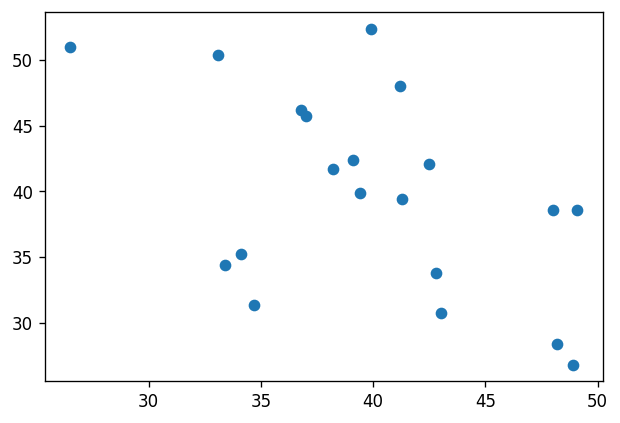

In [13]:
#Plotar o gráfico de dispersão
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.scatter(df['xG'], df['xGA'])

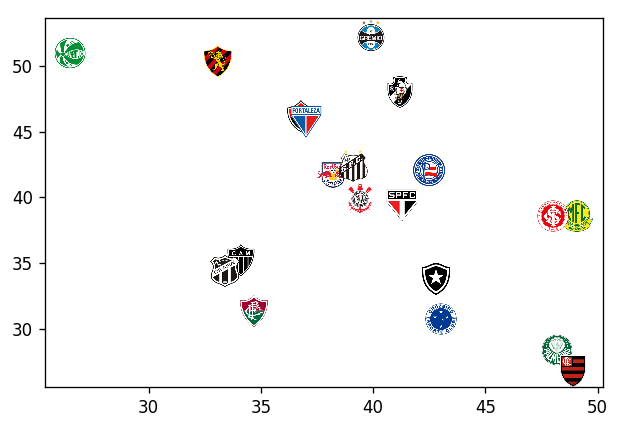

In [14]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import urllib.request
import io

# Plot base
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.scatter(df['xG'], df['xGA'], color='white')

fotmob_url = 'https://images.fotmob.com/image_resources/logo/teamlogo/'

def get_icon_from_url(team_id):
    try:
        with urllib.request.urlopen(f'{fotmob_url}{int(team_id)}.png') as url:
            img_data = url.read()
        img = Image.open(io.BytesIO(img_data))
        
        # Garante que a imagem esteja em RGBA (com fundo transparente tratado corretamente)
        if img.mode != 'RGBA':
            # Se tiver paleta (P) ou RGB sem alfa, converte mantendo fundo transparente
            img = img.convert('RGBA')
        
        # Agora converte para um array NumPy que o matplotlib entende
        img_array = np.array(img)
        
        return OffsetImage(img_array, zoom=0.1, alpha=1.0)
    
    except Exception as e:
        print(f"Erro ao carregar logo do time {team_id}: {e}")
        return None

# Importante: você precisa do numpy!
import numpy as np

for index, row in df.iterrows():
    team_id = row['FotmobId']
    icon = get_icon_from_url(team_id)
    if icon is not None:
        ab = AnnotationBbox(icon, (row['xG'], row['xGA']), frameon=False)
        ax.add_artist(ab)

plt.show()

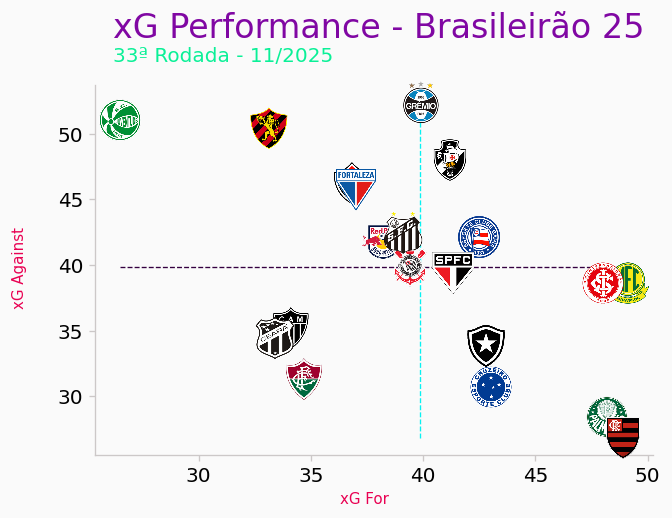

In [16]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import urllib.request
import io
import numpy as np

# === Estilo do gráfico ===
plt.rcParams.update({'font.monospace': 'Courier'})
bgcol = '#fafafa'

# === Criar o gráfico ===
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
fig.set_facecolor(bgcol)
ax.set_facecolor(bgcol)
ax.scatter(df['xG'], df['xGA'], c=bgcol)  # pontos invisíveis, só para definir o espaço

# === Estilizar eixos ===
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#ccc8c8')
ax.spines['bottom'].set_color('#ccc8c8')
plt.tick_params(axis='x', labelsize=12, color='#ccc8c8')
plt.tick_params(axis='y', labelsize=12, color='#ccc8c8')

# === Função para carregar logo do FotMob ===
fotmob_url = 'https://images.fotmob.com/image_resources/logo/teamlogo/'

def get_team_logo(team_id):
    try:
        with urllib.request.urlopen(f'{fotmob_url}{int(team_id)}.png') as response:
            img_data = response.read()
        img = Image.open(io.BytesIO(img_data))
        # Garantir modo RGBA para transparência correta
        if img.mode != 'RGBA':
            img = img.convert('RGBA')
        img_array = np.array(img)
        return OffsetImage(img_array, zoom=0.13, alpha=1.0)  # ajuste zoom conforme necessário
    except Exception as e:
        print(f"Erro ao carregar logo do time {team_id}: {e}")
        return None

# === Adicionar os logos no gráfico ===
for index, row in df.iterrows():
    logo = get_team_logo(row['FotmobId'])
    if logo is not None:
        ab = AnnotationBbox(logo, (row['xG'], row['xGA']), frameon=False)
        ax.add_artist(ab)
        time.sleep(2)

# === Linhas médias ===
xG_mean = df['xG'].mean()
xGA_mean = df['xGA'].mean()
ax.hlines(xGA_mean, df['xG'].min(), df['xG'].max(), color='#340040', linestyle='--', linewidth=0.8)
ax.vlines(xG_mean, df['xGA'].min(), df['xGA'].max(), color='#07F2F2', linestyle='--', linewidth=0.8)

# === Textos ===
fig.text(0.15, 0.98, 'xG Performance - Brasileirão 25', size=20, color='#8007A3', ha='left')
fig.text(0.15, 0.93, '33ª Rodada - 11/2025', size=12, color='#0AF097', ha='left')

fig.text(0.01, 0.50, 'xG Against', size=9, color='#e90052', rotation=90, va='center')
fig.text(0.50, 0.01, 'xG For', size=9, color='#e90052', ha='center')

# === Salvar ===
plt.savefig(r'G:\pythonProject\Aula_Cbf\images\xGChart.png', dpi=1200, bbox_inches="tight", facecolor=bgcol)
plt.show()